Predicting the House Prices (In-Depth Regression Analysis)

Importing all the required Libraries

In [100]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, r2_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, mean_squared_error
from imblearn.over_sampling import SMOTE

Reading the Dataset and doing the EDA on the Dataset

In [3]:
df = pd.read_csv('House_Prices.csv')
df.head(10)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
5,2014-05-02 00:00:00,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,522 NE 88th St,Seattle,WA 98115,USA
6,2014-05-02 00:00:00,335000.0,2.0,2.00,1350,2560,1.0,0,0,3,1350,0,1976,0,2616 174th Ave NE,Redmond,WA 98052,USA
7,2014-05-02 00:00:00,482000.0,4.0,2.50,2710,35868,2.0,0,0,3,2710,0,1989,0,23762 SE 253rd Pl,Maple Valley,WA 98038,USA
8,2014-05-02 00:00:00,452500.0,3.0,2.50,2430,88426,1.0,0,0,4,1570,860,1985,0,46611-46625 SE 129th St,North Bend,WA 98045,USA
9,2014-05-02 00:00:00,640000.0,4.0,2.00,1520,6200,1.5,0,0,3,1520,0,1945,2010,6811 55th Ave NE,Seattle,WA 98115,USA


In [4]:
df.shape

(4600, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### 📌 Feature Engineering: Handling `statezip` Column

During initial data exploration, the `statezip` column was analyzed to understand its structure and usefulness.

- It was observed that all values in `statezip` follow the format: **"WA XXXXX"**
- The prefix **"WA" (state)** is constant across all rows and does not provide any meaningful variation or predictive value.
- The **ZIP code portion (e.g., 98119, 98115, etc.)** varies across observations and represents more granular location information.

#### ✅ Actions Taken:
- Extracted the ZIP code from `statezip` to retain useful geographical information.
- Dropped the original `statezip` column to remove redundancy.
- Stored the extracted ZIP codes as a categorical feature (`zip_code`) for further analysis and encoding.

#### 🎯 Reasoning:
- Constant features do not contribute to model learning and can be safely removed.
- ZIP codes capture neighborhood-level differences, which can significantly impact house prices.
- Transforming raw features into meaningful components improves model performance and interpretability.

#### 🚀 Outcome:
This step ensures that only relevant and informative location-based features are used in the model, reducing noise and improving predictive capability.

In [7]:
df['city'].value_counts()

Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Issaquah                187
Kirkland                187
Kent                    185
Auburn                  176
Sammamish               175
Federal Way             148
Shoreline               123
Woodinville             115
Maple Valley             96
Mercer Island            86
Burien                   74
Snoqualmie               71
Kenmore                  66
Des Moines               58
North Bend               50
Covington                43
Duvall                   42
Lake Forest Park         36
Bothell                  33
Newcastle                33
SeaTac                   29
Tukwila                  29
Vashon                   29
Enumclaw                 28
Carnation                22
Normandy Park            18
Clyde Hill               11
Medina                   11
Fall City                11
Black Diamond             9
Ravensdale                7
Pacific             

In [8]:
df['statezip'].value_counts()

WA 98103    148
WA 98052    135
WA 98117    132
WA 98115    130
WA 98006    110
           ... 
WA 98047      6
WA 98288      3
WA 98050      2
WA 98354      2
WA 98068      1
Name: statezip, Length: 77, dtype: int64

In [9]:
df['statezip'].unique()

array(['WA 98133', 'WA 98119', 'WA 98042', 'WA 98008', 'WA 98052',
       'WA 98115', 'WA 98038', 'WA 98045', 'WA 98155', 'WA 98105',
       'WA 98074', 'WA 98106', 'WA 98007', 'WA 98092', 'WA 98198',
       'WA 98006', 'WA 98102', 'WA 98011', 'WA 98125', 'WA 98003',
       'WA 98136', 'WA 98033', 'WA 98029', 'WA 98117', 'WA 98034',
       'WA 98072', 'WA 98023', 'WA 98107', 'WA 98166', 'WA 98116',
       'WA 98024', 'WA 98055', 'WA 98077', 'WA 98027', 'WA 98059',
       'WA 98075', 'WA 98014', 'WA 98065', 'WA 98199', 'WA 98053',
       'WA 98058', 'WA 98122', 'WA 98103', 'WA 98112', 'WA 98005',
       'WA 98118', 'WA 98177', 'WA 98004', 'WA 98019', 'WA 98144',
       'WA 98168', 'WA 98001', 'WA 98056', 'WA 98146', 'WA 98028',
       'WA 98148', 'WA 98057', 'WA 98040', 'WA 98010', 'WA 98051',
       'WA 98031', 'WA 98109', 'WA 98030', 'WA 98126', 'WA 98032',
       'WA 98178', 'WA 98288', 'WA 98108', 'WA 98070', 'WA 98188',
       'WA 98002', 'WA 98039', 'WA 98022', 'WA 98068', 'WA 980

In [10]:
df['country'].value_counts()

USA    4600
Name: country, dtype: int64

In [11]:
df[(df['city'] == 'Seattle') & (df['statezip'] == 'WA 98119')].shape

(49, 18)

In [12]:
df[(df['city'] == 'Seattle') & (df['statezip'] == 'WA 98115')].shape


(130, 18)

Extracting the zip code from the statezip column

In [13]:
df['zip_code'] = df['statezip'].str.split().str[1]

Droppig the original columns statezip as it is redundant 

In [14]:
df.drop(columns= ['statezip'], inplace= True)

Dropping the street column as it os redundant

In [15]:
df.drop(columns= ['street'], inplace= True)

Dropping the country Column too as its the same across the entire dataset and for this we will just be seeing the house prices for USA

In [16]:
df.drop(columns= ['country'], inplace= True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  city           4600 non-null   object 
 15  zip_code       4600 non-null   object 
dtypes: float64(4), int64(9), object(3)
memory usage: 575.1+ KB


In [18]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


Converting the type of the date Column

In [19]:
df['date'] = pd.to_datetime(df['date'])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[ns]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  city           4600 non-null   object        
 15  zip_code       4600 n

Converting the city and the zip code as a category varibale 

In [21]:
df['city'] = df['city'].astype('category')
df['zip_code'] = df['zip_code'].astype('category')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4600 non-null   datetime64[ns]
 1   price          4600 non-null   float64       
 2   bedrooms       4600 non-null   float64       
 3   bathrooms      4600 non-null   float64       
 4   sqft_living    4600 non-null   int64         
 5   sqft_lot       4600 non-null   int64         
 6   floors         4600 non-null   float64       
 7   waterfront     4600 non-null   int64         
 8   view           4600 non-null   int64         
 9   condition      4600 non-null   int64         
 10  sqft_above     4600 non-null   int64         
 11  sqft_basement  4600 non-null   int64         
 12  yr_built       4600 non-null   int64         
 13  yr_renovated   4600 non-null   int64         
 14  city           4600 non-null   category      
 15  zip_code       4600 n

In [23]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


Checking if there are any null values or not 

In [24]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
city             0
zip_code         0
dtype: int64

Chekcing for the % of null values of the columns which will help in making better decisions on how the columns should do (i.e to keep it or to drop it or to impute it)

In [25]:
(df.isnull().sum() / len(df)) * 100

date             0.0
price            0.0
bedrooms         0.0
bathrooms        0.0
sqft_living      0.0
sqft_lot         0.0
floors           0.0
waterfront       0.0
view             0.0
condition        0.0
sqft_above       0.0
sqft_basement    0.0
yr_built         0.0
yr_renovated     0.0
city             0.0
zip_code         0.0
dtype: float64

#### Now starts the Visualization 📊📈📉

In [26]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


##### First seperating the column into numerical and categorical columns 

In [27]:
# Numerical Columns
num_cols = df.select_dtypes(include= ['int64', 'float64']).columns

# Categorical Columns
cat_cols = df.select_dtypes(include= ['category', 'object']).columns

In [28]:
num_cols

Index(['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated'],
      dtype='object')

In [29]:
cat_cols

Index(['city', 'zip_code'], dtype='object')

##### Visualizing the Numerical Columns

###### (A) Distribution Plots

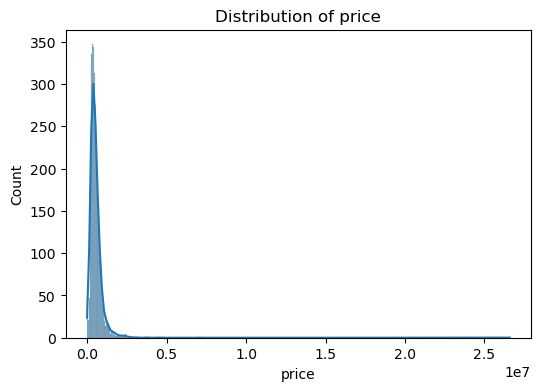

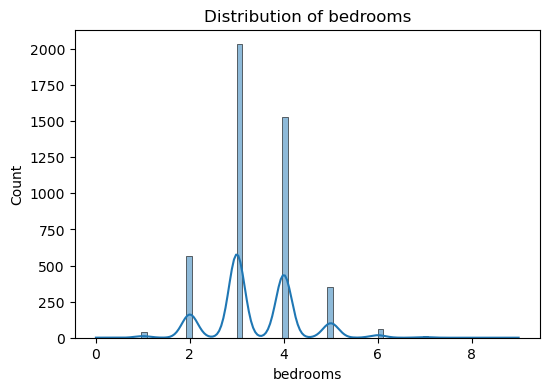

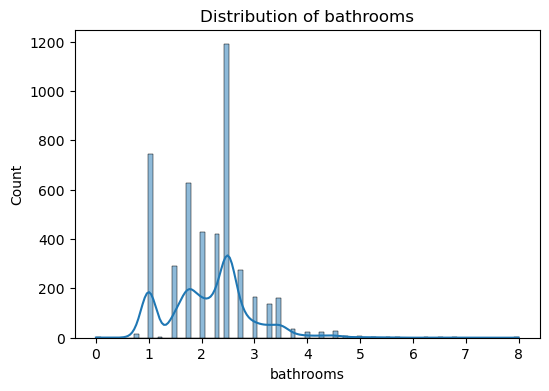

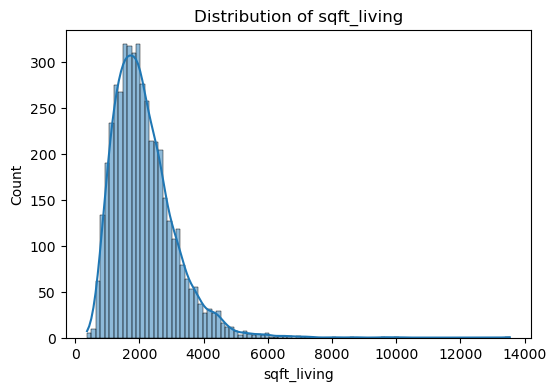

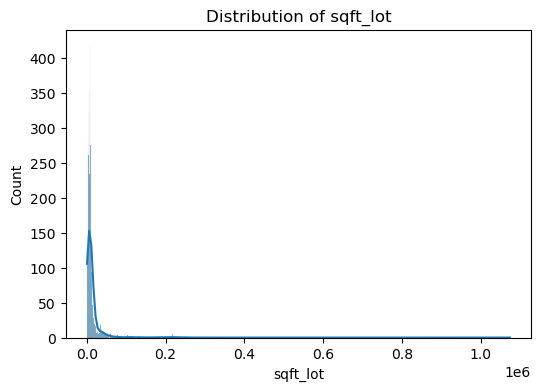

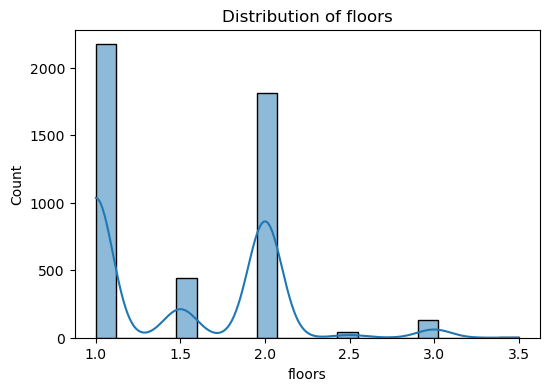

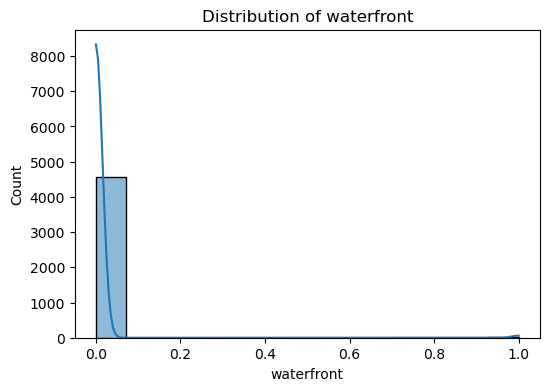

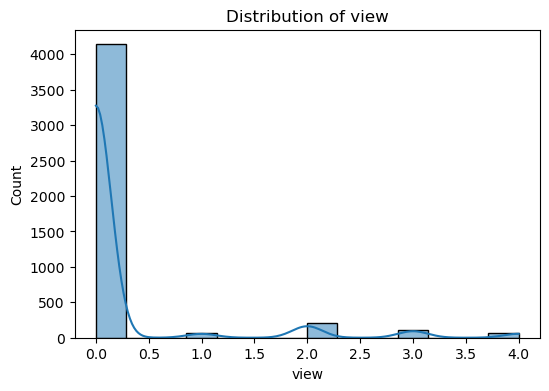

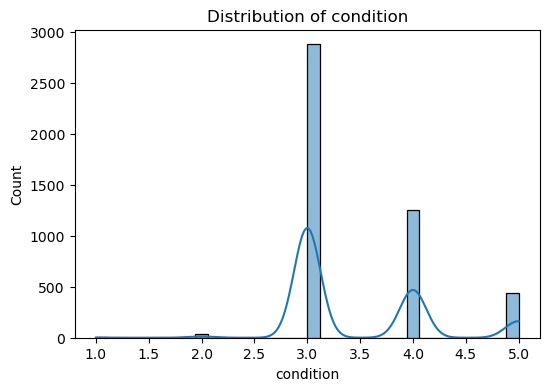

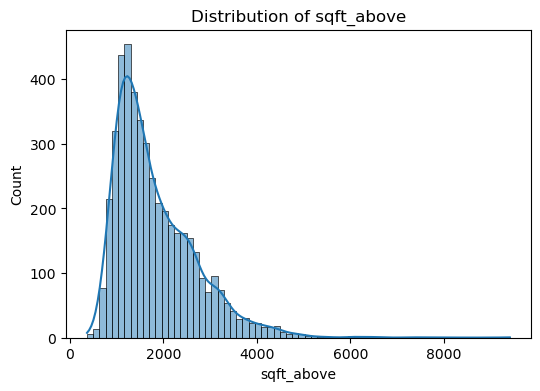

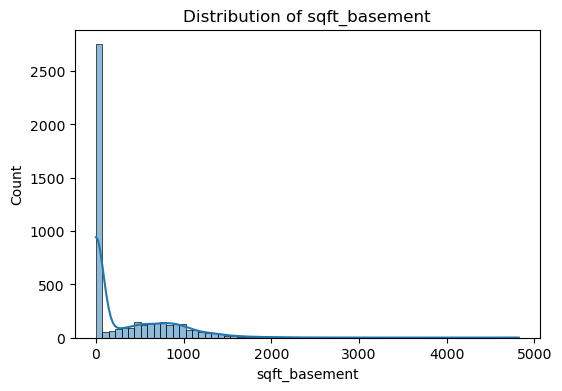

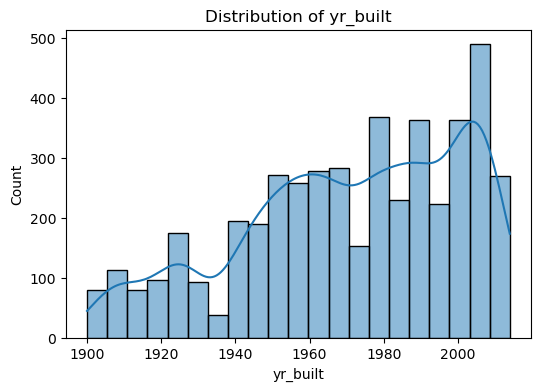

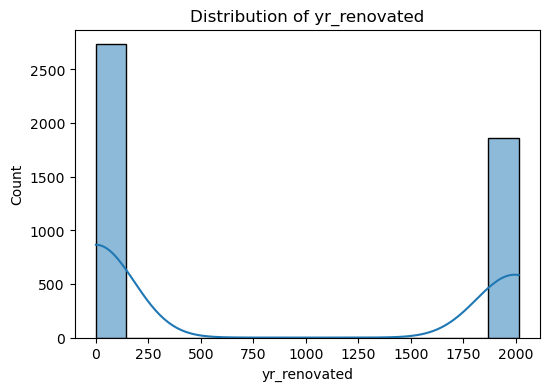

In [30]:
for each_col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(x = each_col, data = df, kde = True)
    plt.title(f'Distribution of {each_col}')
    plt.show()

###### (B) Box Plots 

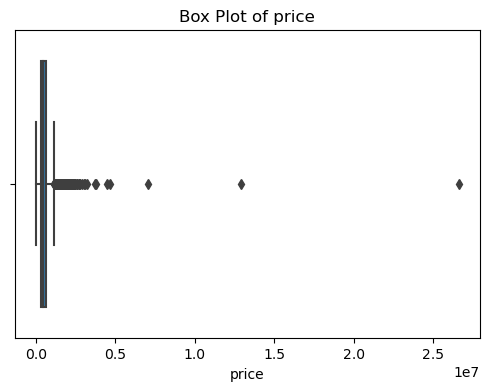

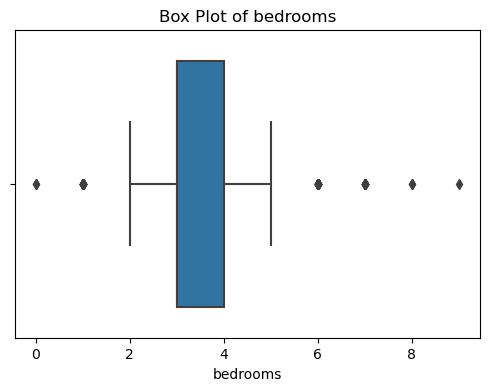

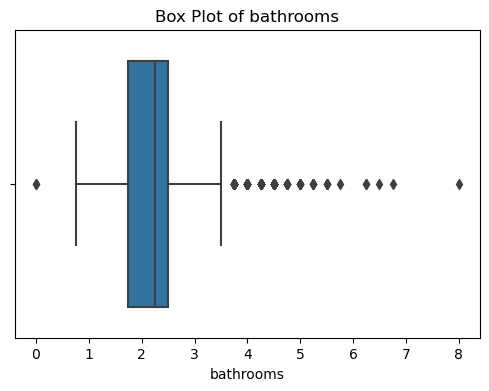

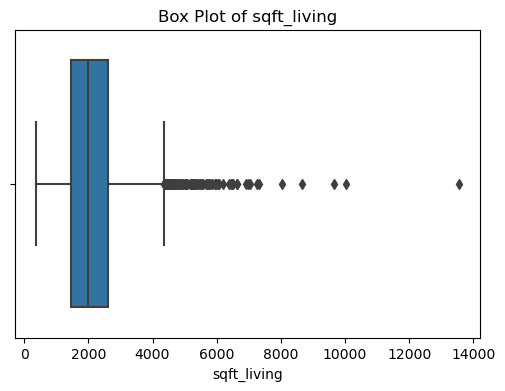

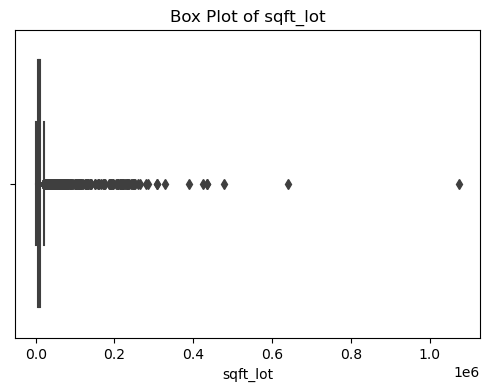

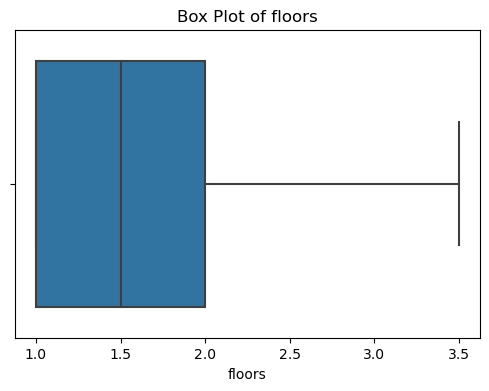

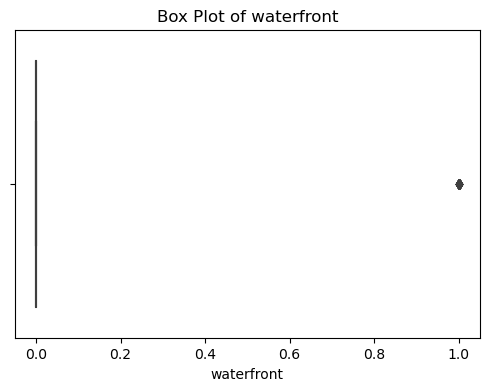

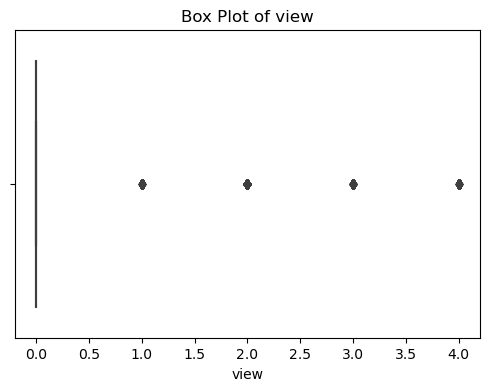

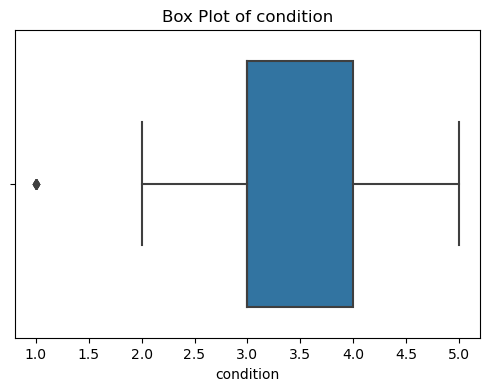

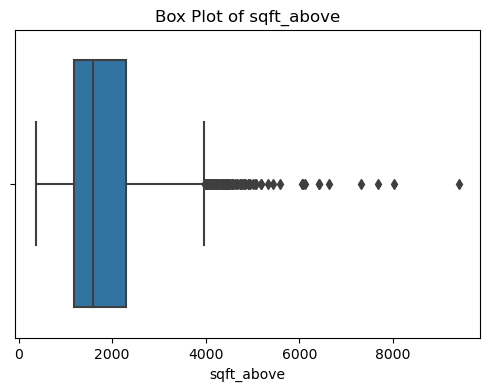

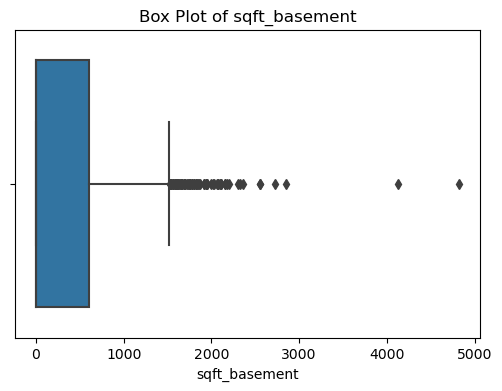

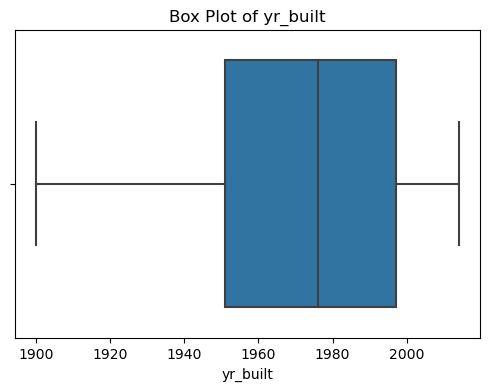

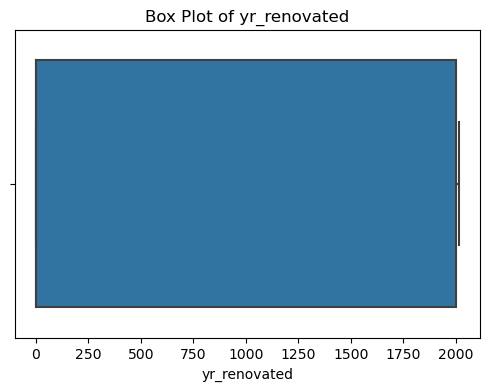

In [31]:
for each_col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x = each_col, data = df)
    plt.title(f'Box Plot of {each_col}')
    plt.show()

##### Visualizing Categorical Variables

###### (A) Count plots

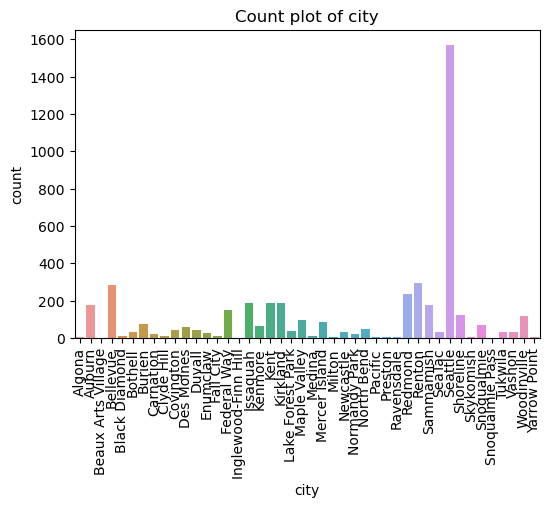

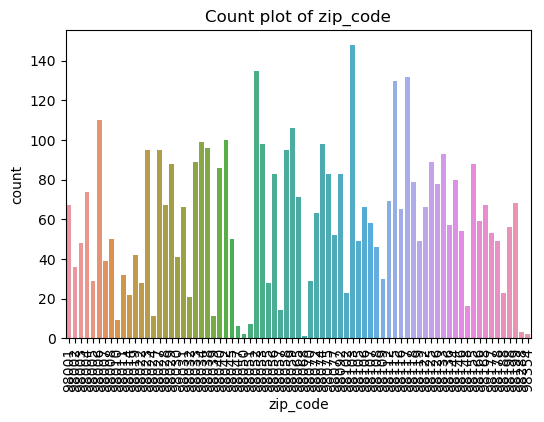

In [32]:
for each_col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x = each_col, data = df)
    plt.title(f'Count plot of {each_col}')
    plt.xticks(rotation = 90)
    plt.show()

##### Target variable Analysis

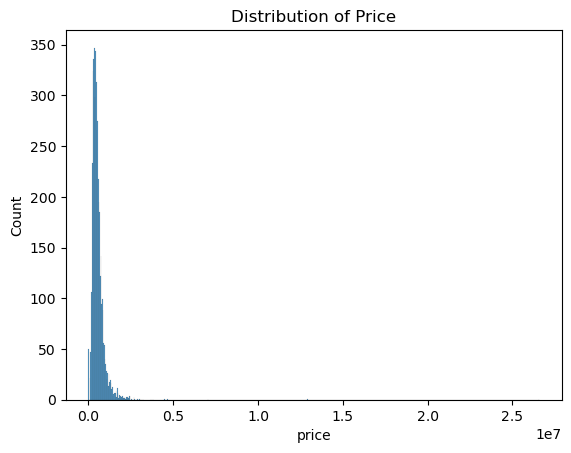

In [33]:
sns.histplot(df['price'])
plt.title('Distribution of Price')
plt.show()

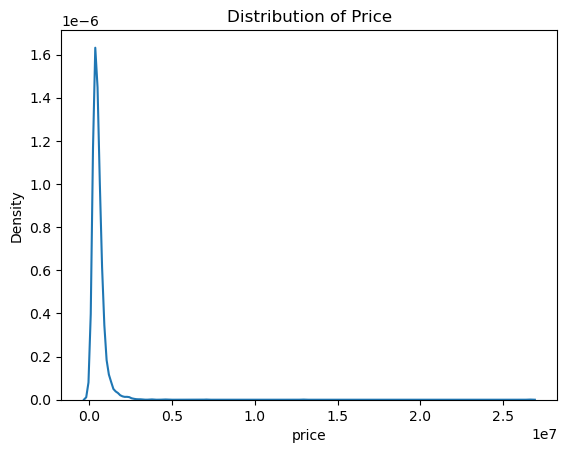

In [34]:
sns.kdeplot(df['price'])
plt.title('Distribution of Price')
plt.show()

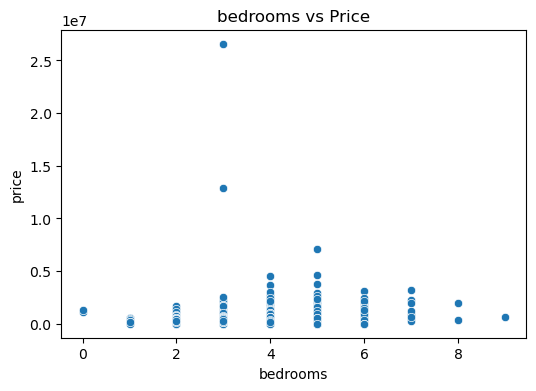

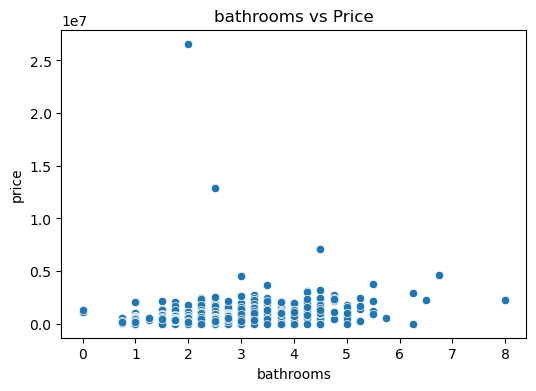

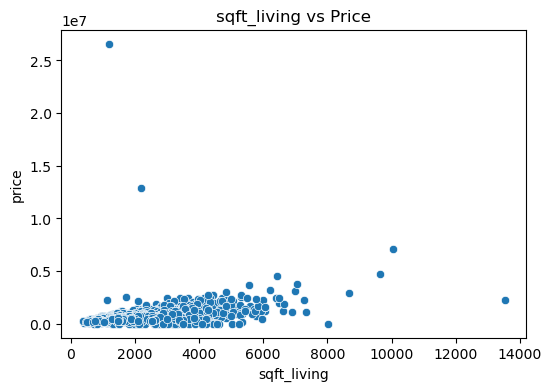

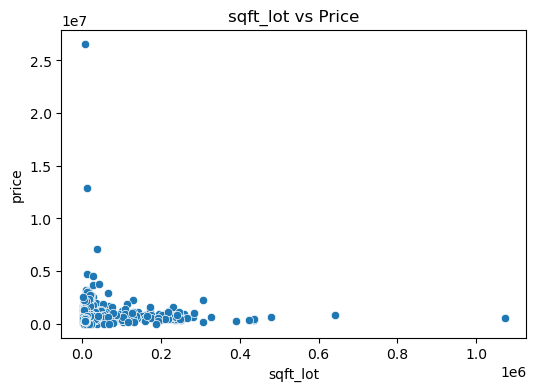

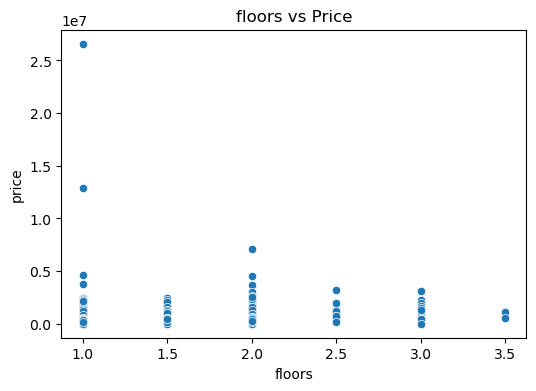

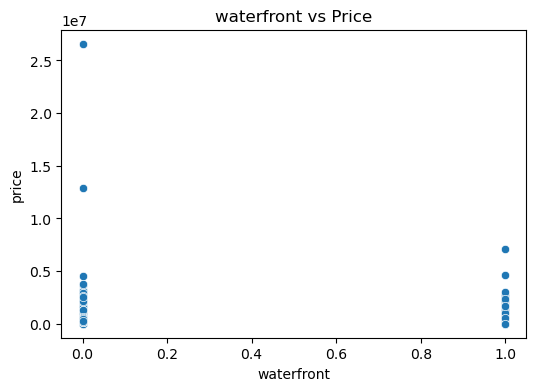

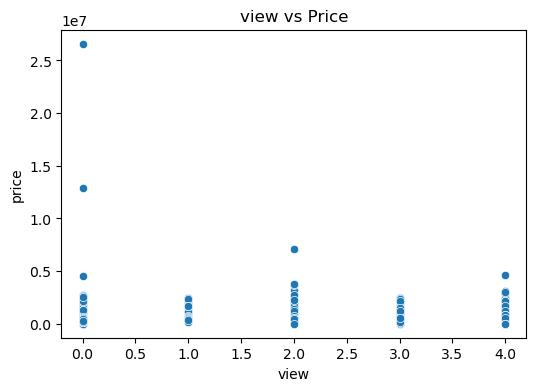

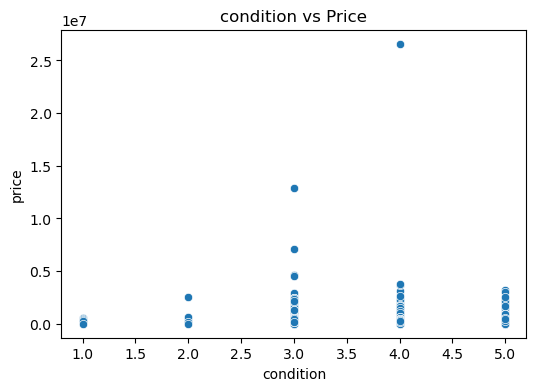

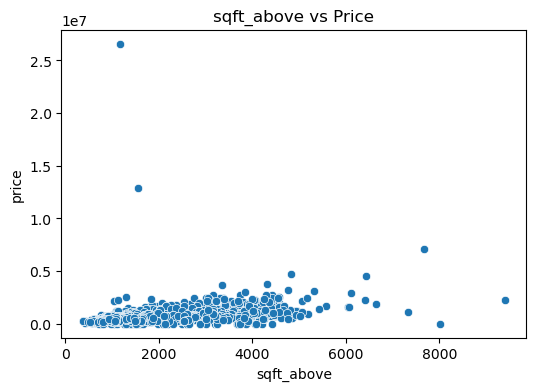

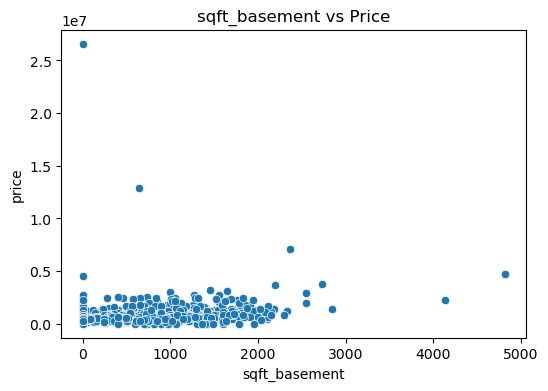

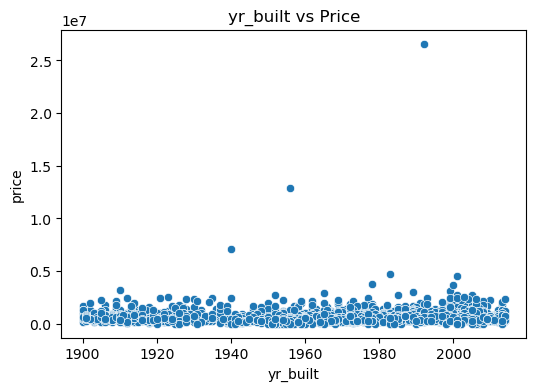

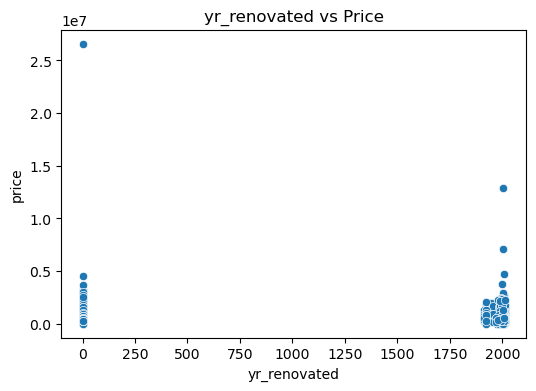

In [35]:
# Numerical V/s target 
for col in num_cols:
    if col != 'price':
        plt.figure(figsize=(6,4))
        sns.scatterplot(x=df[col], y=df['price'])
        plt.title(f'{col} vs Price')
        plt.show()

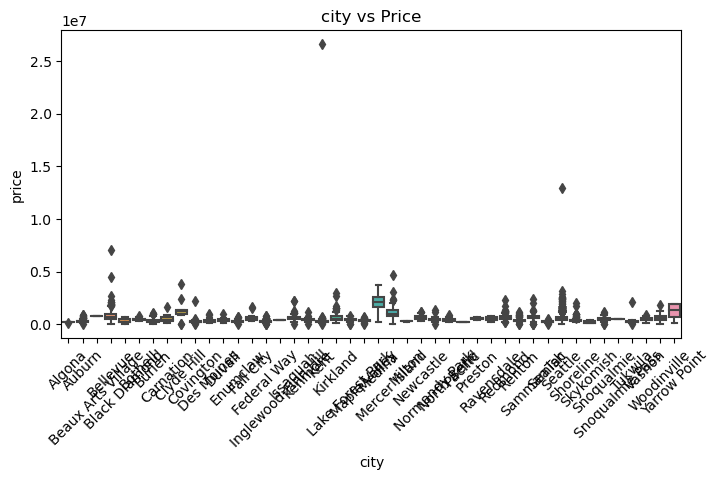

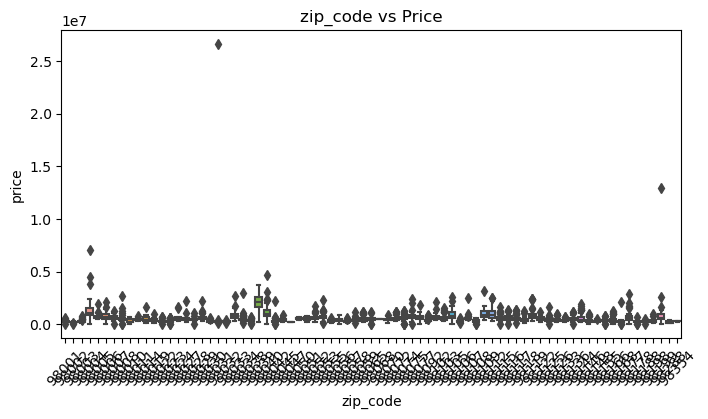

In [36]:
# Categorical V/S Target
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col], y=df['price'])
    plt.title(f'{col} vs Price')
    plt.xticks(rotation=45)
    plt.show()

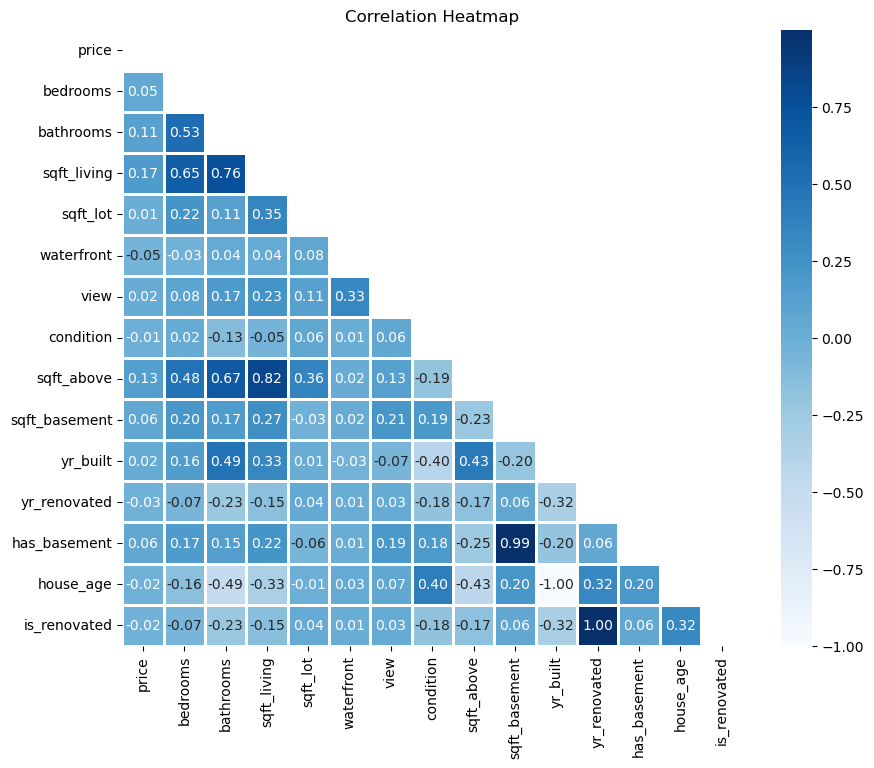

In [58]:
# Heatmap for finding out the multicoliieanerity 
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, 
    annot = True,           # Annotates each cell with the correlation coefficient
    fmt = '.2f',            # Formats the annotations to 2 decimal places
    linewidths = 0.725,     # Adds a line between cells
    linecolor = 'white',    # Color of the lines between cells
    mask = np.triu(corr),   # Masks the upper triangle of the heatmap to avoid redundancy
    cmap = 'Blues')


plt.title('Correlation Heatmap')
plt.show()

In [38]:
df_main = df.copy()

In [39]:
df_main.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052


### Now doing the required Transformation And removing of the columns as needed from the plots above 

#### Basement Feature

In [40]:
df['has_basement'] = (df['sqft_basement'] > 0).astype(int)

#### Conversion of year built to house age as it makes the most sense rather than the house year built

In [41]:
df['house_age'] = 2026 - df['yr_built']

#### Renovation Feature

In [42]:
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)

In [43]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133,0,71,1
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,98119,1,105,0
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042,0,60,0
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008,1,63,0
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052,1,50,1


### Handling the Outlier

#### Bedroom Cleaning

In [44]:
df = df[(df['bedrooms'] > 0) & (df['bedrooms'] < 7)]

#### Pricing outlier Capping and then applying the log transfrom on it to remove the outliers and the skweness of the data too


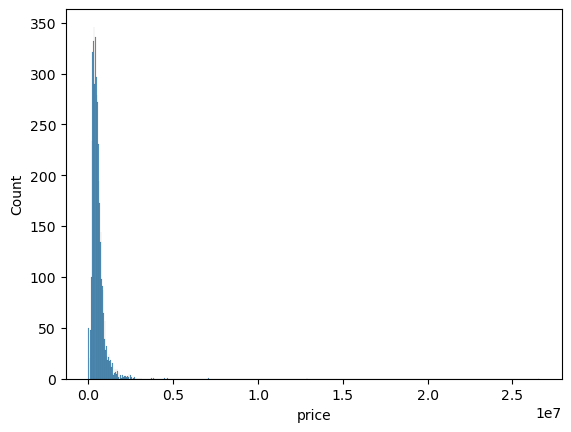

In [45]:
sns.histplot(x = 'price', data = df)
plt.show()

In [46]:
df = df[df['price'] < df['price'].quantile(0.99)]   # Quantiling

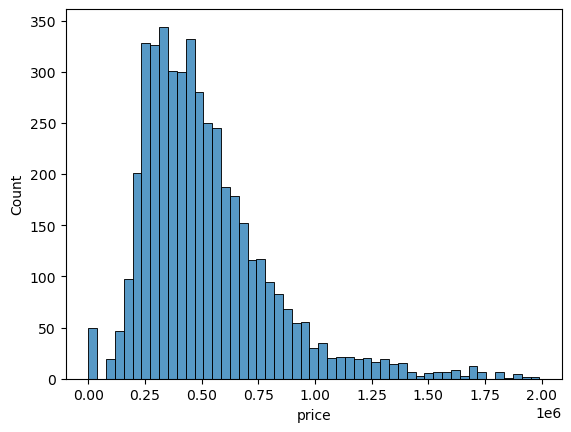

In [47]:
sns.histplot(x = 'price', data = df)
plt.show()

In [48]:
df['price'] = np.log1p(df['price']) # Log transformation of the data 

#### 📊 What your histogram is telling you

From your plot:

Distribution is now much more symmetric ✅
Most values are centered around 12–13 (log scale)
Very few extreme values
Slight spike near 0 → likely original prices that were 0 or very small ⚠️

👉 Overall: Your target is now well-behaved

🧠 What this means

You have successfully:

✅ Reduced skewness
✅ Controlled outliers
✅ Made target closer to normal distribution

👉 This is ideal for regression models, especially:

Linear Regression

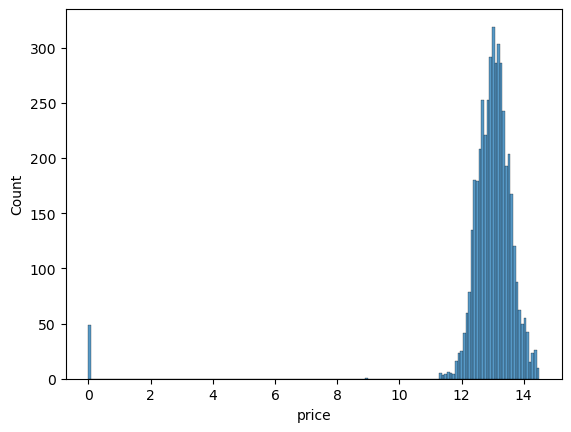

In [49]:
sns.histplot(x = 'price', data = df)
plt.show()

In [50]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,12.653962,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,98133,0,71,1
2,2014-05-02,12.742569,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,98042,0,60,0
3,2014-05-02,12.948012,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,98008,1,63,0
4,2014-05-02,13.217675,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,98052,1,50,1
5,2014-05-02,13.102163,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,Seattle,98115,0,88,1


#### Log transform on sqft_basement, sqft_living, sqft_lot

In [51]:
df['sqft_basement'] = np.log1p(df['sqft_basement'])
df['sqft_living'] = np.log1p(df['sqft_living'])
df['sqft_lot'] = np.log1p(df['sqft_lot'])

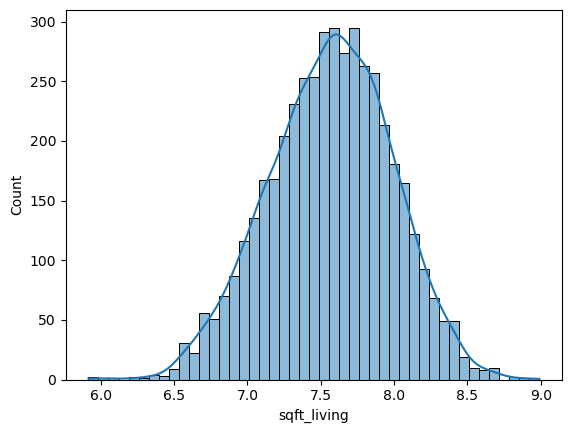

In [52]:
sns.histplot(x = 'sqft_living', data = df, kde = True)
plt.show()

#### Converting all the required colums into particular category column


In [53]:
df['floors'] = df['floors'].astype('category')


In [56]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,12.653962,3.0,1.50,7.201171,8.976262,1.5,0,0,3,1340,0.000000,1955,2005,Shoreline,98133,0,71,1
2,2014-05-02,12.742569,3.0,2.00,7.565793,9.388319,1.0,0,0,4,1930,0.000000,1966,0,Kent,98042,0,60,0
3,2014-05-02,12.948012,3.0,2.25,7.601402,8.991064,1.0,0,0,4,1000,6.908755,1963,0,Bellevue,98008,1,63,0
4,2014-05-02,13.217675,4.0,2.50,7.570959,9.259226,1.0,0,0,4,1140,6.685861,1976,1992,Redmond,98052,1,50,1
5,2014-05-02,13.102163,2.0,1.00,6.781058,8.761080,1.0,0,0,3,880,0.000000,1938,1994,Seattle,98115,0,88,1


In [57]:
df.dtypes

date             datetime64[ns]
price                   float64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                 category
waterfront                int64
view                      int64
condition                 int64
sqft_above                int64
sqft_basement           float64
yr_built                  int64
yr_renovated              int64
city                   category
zip_code               category
has_basement              int32
house_age                 int64
is_renovated              int32
dtype: object

#### Dropping all the unnesscary column

In [59]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'zip_code',
       'has_basement', 'house_age', 'is_renovated'],
      dtype='object')

In [ ]:
df.drop(columns= ['sqft_above', 'yr_built', 'yr_renovated'], inplace = True)

In [61]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,12.653962,3.0,1.50,7.201171,8.976262,1.5,0,0,3,0.000000,Shoreline,98133,0,71,1
2,2014-05-02,12.742569,3.0,2.00,7.565793,9.388319,1.0,0,0,4,0.000000,Kent,98042,0,60,0
3,2014-05-02,12.948012,3.0,2.25,7.601402,8.991064,1.0,0,0,4,6.908755,Bellevue,98008,1,63,0
4,2014-05-02,13.217675,4.0,2.50,7.570959,9.259226,1.0,0,0,4,6.685861,Redmond,98052,1,50,1
5,2014-05-02,13.102163,2.0,1.00,6.781058,8.761080,1.0,0,0,3,0.000000,Seattle,98115,0,88,1


### Final Feature Selection

In [87]:
features = [
    'sqft_living',
    'bathrooms',
    'bedrooms',
    'floors',
    'waterfront',
    'view',
    'condition',
    'sqft_basement',
    'has_basement',
    'house_age',
    'is_renovated',
    'zip_code',
    'city'
]

X = df[features]
y = df['price']

In [88]:
X.head()

,sqft_living,bathrooms,bedrooms,floors,waterfront,view,condition,sqft_basement,has_basement,house_age,is_renovated,zip_code,city
0,7.201171,1.50,3.0,1.5,0,0,3,0.000000,0,71,1,98133,Shoreline
2,7.565793,2.00,3.0,1.0,0,0,4,0.000000,0,60,0,98042,Kent
3,7.601402,2.25,3.0,1.0,0,0,4,6.908755,1,63,0,98008,Bellevue
4,7.570959,2.50,4.0,1.0,0,0,4,6.685861,1,50,1,98052,Redmond
5,6.781058,1.00,2.0,1.0,0,0,3,0.000000,0,88,1,98115,Seattle


In [90]:
X_linear_model = pd.get_dummies(X, columns=['zip_code', 'floors', 'city'], drop_first=True)
X_random_forest_model = pd.get_dummies(X, columns=['zip_code', 'floors', 'city'], drop_first=True)

## Linear Regression

### Train test split for linear Model

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X_linear_model, y, test_size=0.2, random_state= 100)

### Scaling as it is a linear model (Works on distance method)

In [94]:
scaler = StandardScaler()   # Making the object of the StandardScaler Class

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model Building (Linear Regression)

In [106]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)

In [107]:
y_pred = linear_model.predict(X_test)

# Converting back to original Scale
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

c:\Users\Jeffrey\anaconda3\lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_80988\936584143.py:5: RuntimeWarning: overflow encountered in expm1
  y_pred_exp = np.expm1(y_pred)


### Metrics of Linear Regression

In [109]:
print(f'R2 Score : {r2_score(y_test_exp, y_pred_exp)}')


ValueError: Input contains infinity or a value too large for dtype('float64').

## Random Forest

### Train test split


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_random_forest_model, y, test_size=0.2, random_state= 100)

### Model Building (Random Forest)

In [117]:
rf = RandomForestRegressor(
    n_estimators=300,
    
)

rf.fit(X_train, y_train)



RandomForestRegressor(n_estimators=300)

In [118]:
y_pred = rf.predict(X_test)

# Converting back to original Scale
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)


### Metrics of Random Forest

In [119]:
print(f'R2 Score : {r2_score(y_test_exp, y_pred_exp)}')


R2 Score : 0.4238641015376158


### Seeing the feature Importances

In [122]:
importances = rf.feature_importances_

feature_names = X_train.columns

for name, val in zip(feature_names, importances):
    print(name, val)

sqft_living 0.16624835597471618
bathrooms 0.12743693184995133
bedrooms 0.0846206997292678
waterfront 0.015267685775298214
view 0.03597703110002538
condition 0.038046729101902245
sqft_basement 0.05827797938702989
has_basement 0.009852567970398374
house_age 0.08929287577961667
is_renovated 0.012839707117900853
zip_code_98002 7.512123577679493e-05
zip_code_98003 0.0003601304191519446
zip_code_98004 0.008435381105163939
zip_code_98005 4.4787407782822195e-05
zip_code_98006 0.00032720620594450713
zip_code_98007 0.006758535824758972
zip_code_98008 0.008529103334906621
zip_code_98010 0.004562450688434046
zip_code_98011 4.362842701739115e-05
zip_code_98014 8.125818571819798e-05
zip_code_98019 0.00012588483677492712
zip_code_98022 0.0001393332669654785
zip_code_98023 0.0068219993575983715
zip_code_98024 1.077487915928391e-05
zip_code_98027 0.00010590488662299575
zip_code_98028 0.0023428207837234063
zip_code_98029 6.182133336816309e-05
zip_code_98030 0.00034848805124802865
zip_code_98031 5.567117

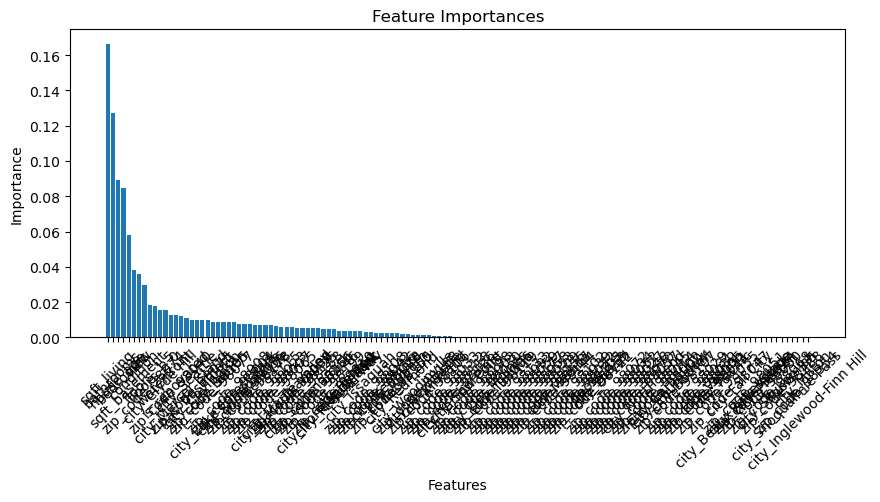

In [123]:
# Create a DataFrame for easy sorting and plotting
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feat_importances = feat_importances.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,4))
plt.bar(feat_importances['Feature'], feat_importances['Importance'])
plt.xticks(rotation=45)
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### From this able to figure out that one hot encoding is creating a lot of noise, so we have to fix that, adding of the column, total_sq_ft, trying the XGBoost

In [124]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,city,zip_code,has_basement,house_age,is_renovated
0,2014-05-02,12.653962,3.0,1.50,7.201171,8.976262,1.5,0,0,3,0.000000,Shoreline,98133,0,71,1
2,2014-05-02,12.742569,3.0,2.00,7.565793,9.388319,1.0,0,0,4,0.000000,Kent,98042,0,60,0
3,2014-05-02,12.948012,3.0,2.25,7.601402,8.991064,1.0,0,0,4,6.908755,Bellevue,98008,1,63,0
4,2014-05-02,13.217675,4.0,2.50,7.570959,9.259226,1.0,0,0,4,6.685861,Redmond,98052,1,50,1
5,2014-05-02,13.102163,2.0,1.00,6.781058,8.761080,1.0,0,0,3,0.000000,Seattle,98115,0,88,1


#### ✅ FIX (VERY IMPORTANT)

Use Target Encoding: Zip Code and City too


In [156]:
df['zip_code_encoded'] = df.groupby('zip_code')['price'].transform('mean')
df['city_encoded'] = df.groupby('city')['price'].transform('mean')

df.drop(columns=['city', 'zip_code'], inplace=True)

In [157]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_basement,has_basement,house_age,is_renovated,zip_code_encoded,city_encoded
0,2014-05-02,12.653962,3.0,1.50,7.201171,8.976262,1.5,0,0,3,0.000000,0,71,1,12.803063,12.847181
2,2014-05-02,12.742569,3.0,2.00,7.565793,9.388319,1.0,0,0,4,0.000000,0,60,0,12.319984,12.498782
3,2014-05-02,12.948012,3.0,2.25,7.601402,8.991064,1.0,0,0,4,6.908755,1,63,0,12.683702,13.254664
4,2014-05-02,13.217675,4.0,2.50,7.570959,9.259226,1.0,0,0,4,6.685861,1,50,1,13.326375,13.349113
5,2014-05-02,13.102163,2.0,1.00,6.781058,8.761080,1.0,0,0,3,0.000000,0,88,1,13.147814,13.016476


In [164]:
# remove all the necessary columsn that you dont require,